**Cogs 105: Final Project - Speed Dating Experiment**

Notebook Overview
- Exploratory Data Analysis 
- Data Preparation
- Model A: Baseline Predictive Model
- Model B: Ratings-Based Predictive Model

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV

In [31]:
df = pd.read_csv(
    "Speed Dating Data.csv",
    encoding="latin1", #this dataset required specifying a Latin-1 encoding to properly load all survey responses (helped with ChatGPT)
    header=0,
    skiprows=[1]
)

df.shape

(8377, 195)

Exploratory Data Analysis

In [32]:
df.columns[:15]

Index(['iid', 'id', 'gender', 'idg', 'condtn', 'wave', 'round', 'position',
       'positin1', 'order', 'partner', 'pid', 'match', 'int_corr', 'samerace'],
      dtype='object')

In [33]:
df.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,6,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [34]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8377 entries, 0 to 8376
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), object(8)
memory usage: 12.5+ MB


Index(['iid', 'id', 'gender', 'idg', 'condtn', 'wave', 'round', 'position',
       'positin1', 'order',
       ...
       'attr3_3', 'sinc3_3', 'intel3_3', 'fun3_3', 'amb3_3', 'attr5_3',
       'sinc5_3', 'intel5_3', 'fun5_3', 'amb5_3'],
      dtype='object', length=195)

In [35]:
df["match"].value_counts(dropna=False)

match
0    6997
1    1380
Name: count, dtype: int64

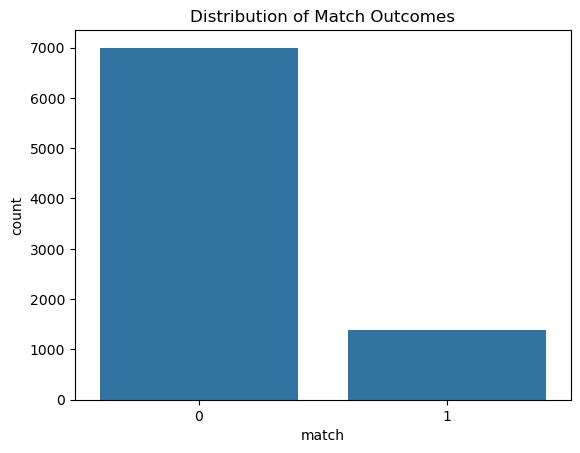

In [36]:
sns.countplot(x="match", data=df)
plt.title("Distribution of Match Outcomes")
plt.show()

In [37]:
#missing data analysis 

missing_prop = df.isna().mean().sort_values(ascending=False)
missing_prop.head(15)

num_in_3    0.920258
numdat_3    0.821416
expnum      0.785245
sinc7_2     0.766623
amb7_2      0.766623
shar7_2     0.764355
attr7_2     0.763161
intel7_2    0.763161
fun7_2      0.763161
amb5_3      0.759341
attr7_3     0.759341
sinc7_3     0.759341
intel7_3    0.759341
fun7_3      0.759341
amb7_3      0.759341
dtype: float64

In [38]:
missing_prop.describe()

count    195.000000
mean       0.264424
std        0.280366
min        0.000000
25%        0.010624
50%        0.109228
75%        0.522502
max        0.920258
dtype: float64

In [39]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8377 entries, 0 to 8376
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), object(8)
memory usage: 12.5+ MB


Exploratory Data Analysis - Demographics

In [40]:
#labeled gender and match variable for more readable plots 
df["gender_label"] = df["gender"].map({0: "Female", 1: "Male"})
df["match_label"] = df["match"].map({0: "No Match", 1: "Match"})

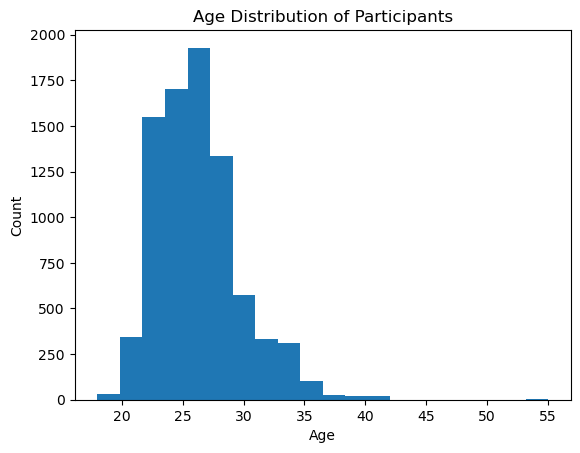

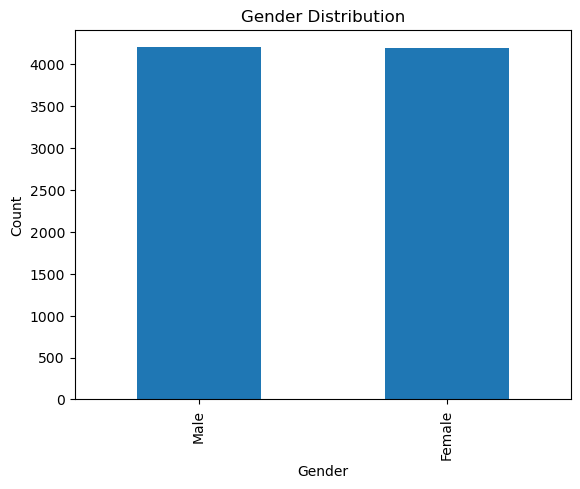

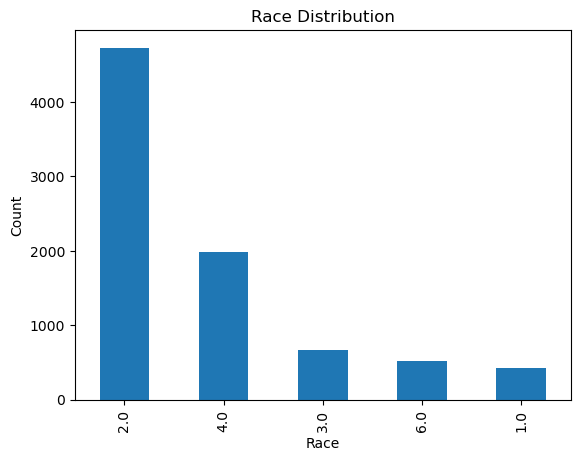

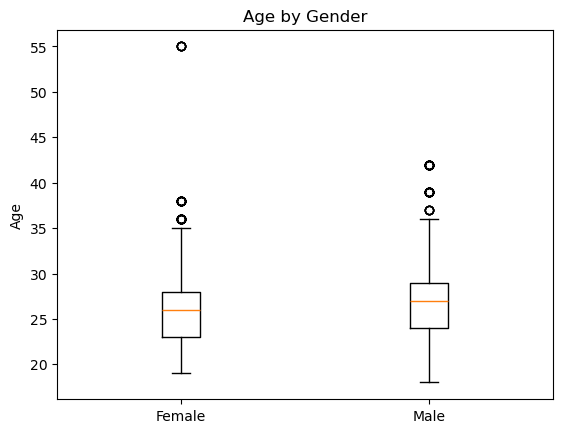

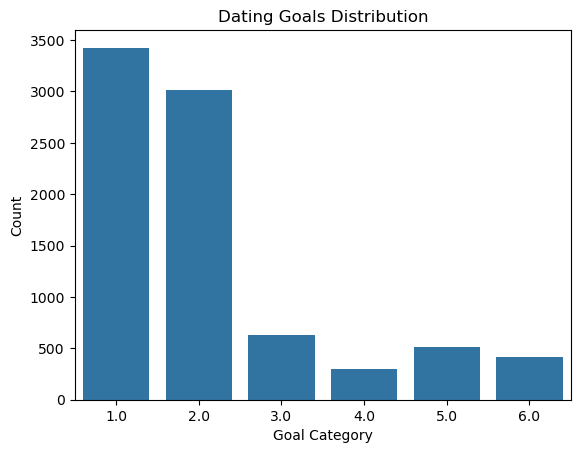

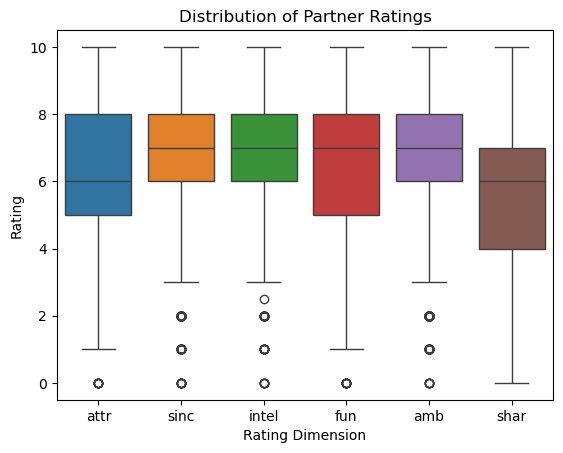

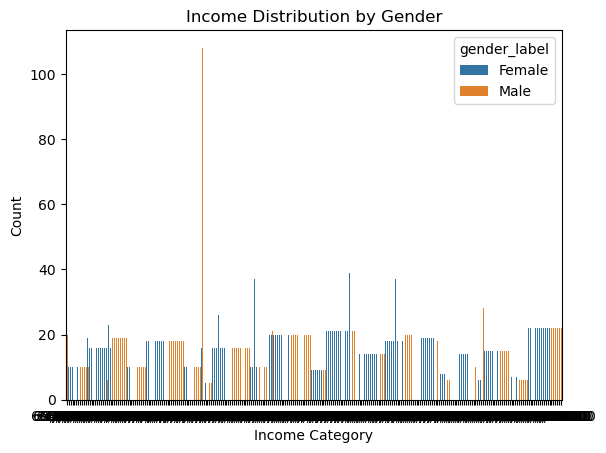

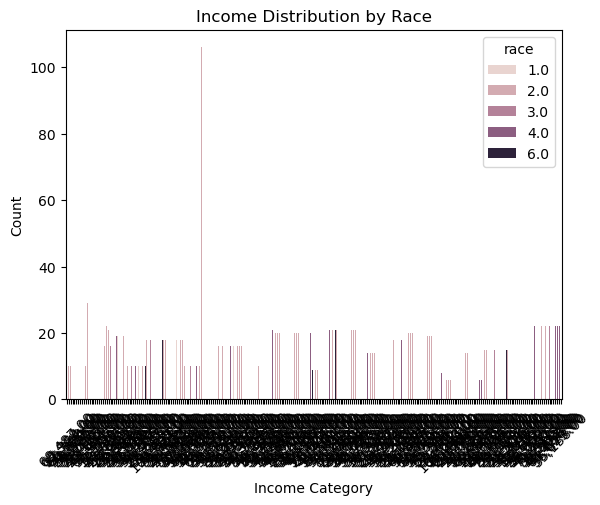

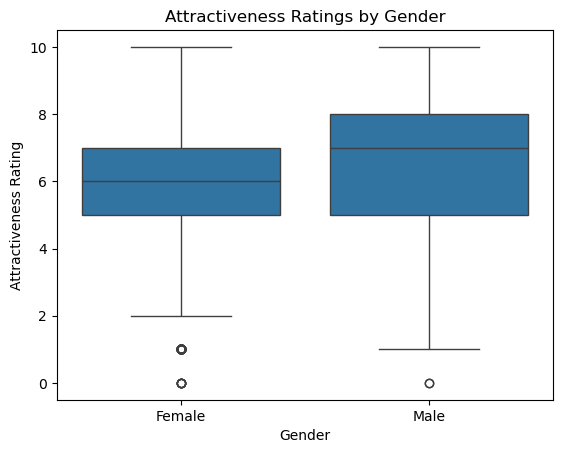

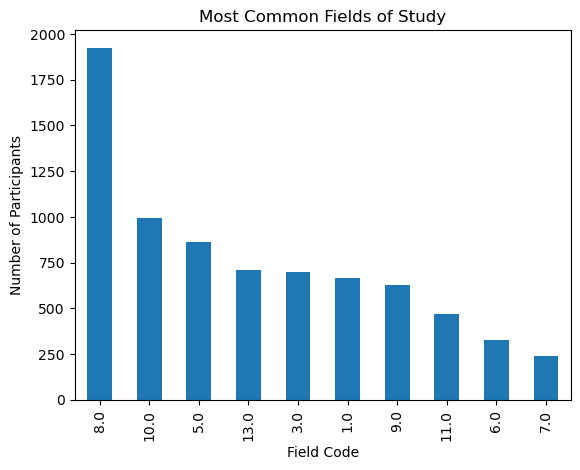

In [41]:
# Age distribution
df["age"].describe()

plt.hist(df["age"].dropna(), bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of Participants")
plt.show()

# Gender distribution 
df["gender_label"].value_counts()

df["gender_label"].value_counts().plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")
plt.show()

# Race distribution
df["race"].value_counts()

df["race"].value_counts().plot(kind="bar")
plt.xlabel("Race")
plt.ylabel("Count")
plt.title("Race Distribution")
plt.show()

# Age by gender
df.groupby("gender")["age"].describe()

plt.boxplot(
    [
        df[df["gender"] == 0]["age"].dropna(),
        df[df["gender"] == 1]["age"].dropna()
    ],
    labels=["Female", "Male"]
)
plt.ylabel("Age")
plt.title("Age by Gender")
plt.show()

# Field of study
df["field"].value_counts().head(10)

# Dating goals distribution
sns.countplot(data=df, x="goal")
plt.title("Dating Goals Distribution")
plt.xlabel("Goal Category")
plt.ylabel("Count")
plt.show()

# Partner ratings distribution
rating_vars = ["attr", "sinc", "intel", "fun", "amb", "shar"]

sns.boxplot(data=df[rating_vars])
plt.title("Distribution of Partner Ratings")
plt.xlabel("Rating Dimension")
plt.ylabel("Rating")
plt.show()

# Income by gender 
sns.countplot(data=df, x="income", hue="gender_label")
plt.title("Income Distribution by Gender")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()

# Income by race
sns.countplot(data=df, x="income", hue="race")
plt.title("Income Distribution by Race")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Attractiveness ratings by gender 
sns.boxplot(data=df, x="gender_label", y="attr")
plt.title("Attractiveness Ratings by Gender")
plt.xlabel("Gender")
plt.ylabel("Attractiveness Rating")
plt.show()

# Descriptive statistics
df["income"].describe()

# Most common fields of study
df["field_cd"].value_counts().head(10).plot(kind="bar")
plt.title("Most Common Fields of Study")
plt.ylabel("Number of Participants")
plt.xlabel("Field Code")
plt.show()

Exploratory Data Analysis - Dating Interactions

We'll use df to learn more about each of the dating interactions themselves. some participants had more than one date, so we have a total of 8378 interactions.

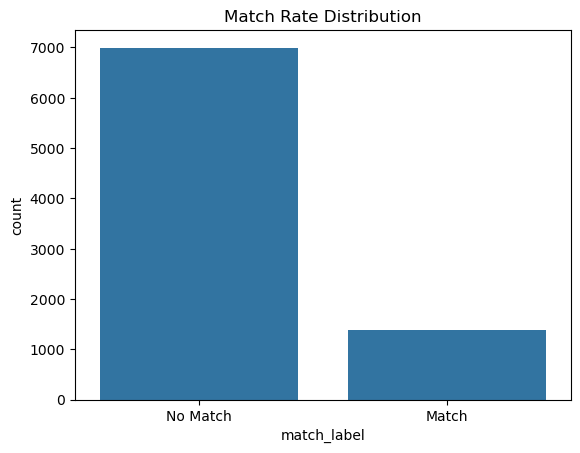

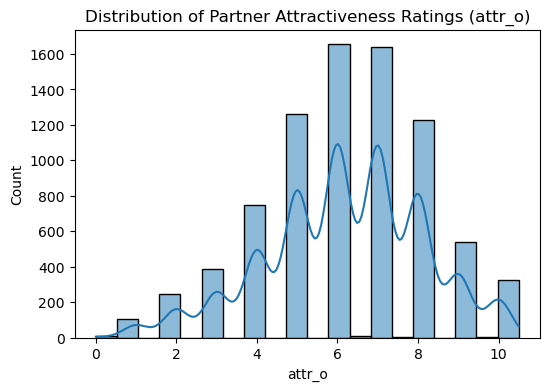

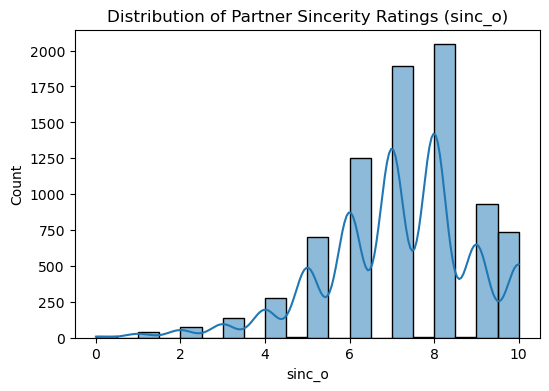

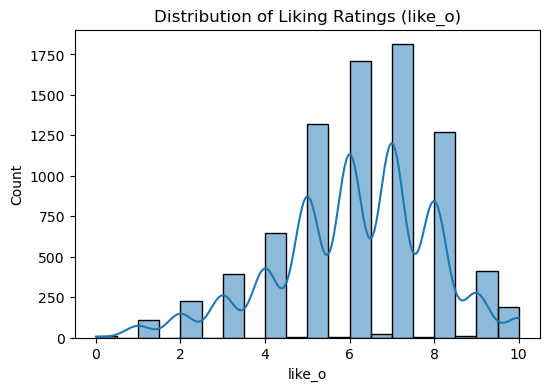

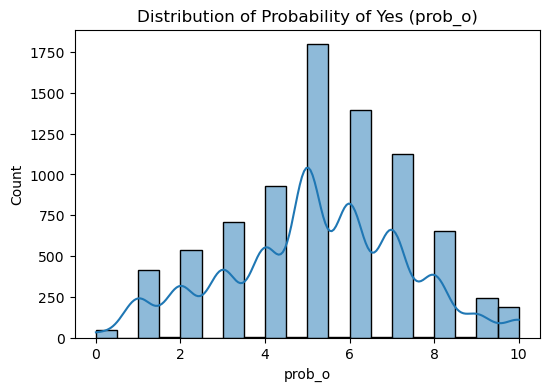

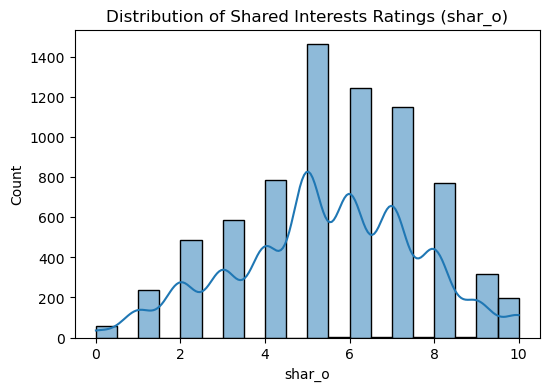

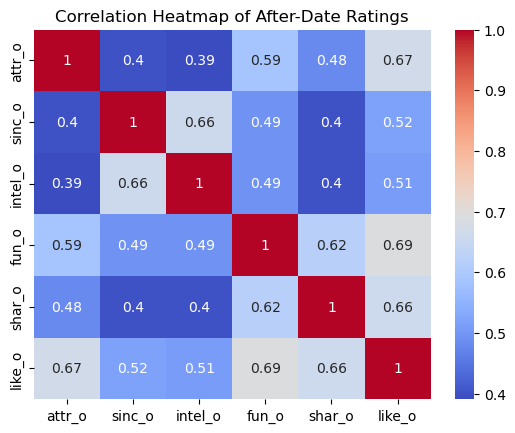

In [42]:
#match rate
sns.countplot(data=df, x='match_label')
plt.title("Match Rate Distribution")
plt.show() 

#ratings particiapnts gave to their dates
# partner attractiveness (attr_o)
plt.figure(figsize=(6,4))
sns.histplot(df['attr_o'], kde=True, bins=20)
plt.title('Distribution of Partner Attractiveness Ratings (attr_o)')
plt.xlabel('attr_o')
plt.ylabel('Count')
plt.show()

# partner sincerity (sinc_o)
plt.figure(figsize=(6,4))
sns.histplot(df['sinc_o'], kde=True, bins=20)
plt.title('Distribution of Partner Sincerity Ratings (sinc_o)')
plt.xlabel('sinc_o')
plt.ylabel('Count')
plt.show()

# liking (like_o)
plt.figure(figsize=(6,4))
sns.histplot(df['like_o'], kde=True, bins=20)
plt.title('Distribution of Liking Ratings (like_o)')
plt.xlabel('like_o')
plt.ylabel('Count')
plt.show()

# probability of saying yes (prob_o)
plt.figure(figsize=(6,4))
sns.histplot(df['prob_o'], kde=True, bins=20)
plt.title('Distribution of Probability of Yes (prob_o)')
plt.xlabel('prob_o')
plt.ylabel('Count')
plt.show()

# shared interests (shar_o)
plt.figure(figsize=(6,4))
sns.histplot(df['shar_o'], kde=True, bins=20)
plt.title('Distribution of Shared Interests Ratings (shar_o)')
plt.xlabel('shar_o')
plt.ylabel('Count')
plt.show()


#correlation heatmap of after-date ratings
ratings = df[['attr_o','sinc_o','intel_o','fun_o','shar_o','like_o']]
sns.heatmap(ratings.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of After-Date Ratings")
plt.show()

AVERAGE PREFERENCE SCORES: MATCHES vs NO MATCHES

Average Preference Scores:
          No Match (0)  Match (1)  Difference
attr1_1          24.11      23.77       -0.34
sinc1_1          17.00      15.94       -1.07
intel1_1         21.72      22.06        0.34
fun1_1           17.19      18.58        1.39
amb1_1            9.87       9.46       -0.41
shar1_1          10.78      10.69       -0.09
pf_o_att         24.00      23.77       -0.23
pf_o_sin         17.00      15.94       -1.07
pf_o_int         21.76      22.06        0.30
pf_o_fun         17.20      18.58        1.38
pf_o_amb          9.89       9.46       -0.43
pf_o_sha         10.79      10.69       -0.09

Sorted by Biggest Difference (Match - No Match):
          No Match (0)  Match (1)  Difference
fun1_1           17.19      18.58        1.39
pf_o_fun         17.20      18.58        1.38
intel1_1         21.72      22.06        0.34
pf_o_int         21.76      22.06        0.30
shar1_1          10.78      10.69       -0.09

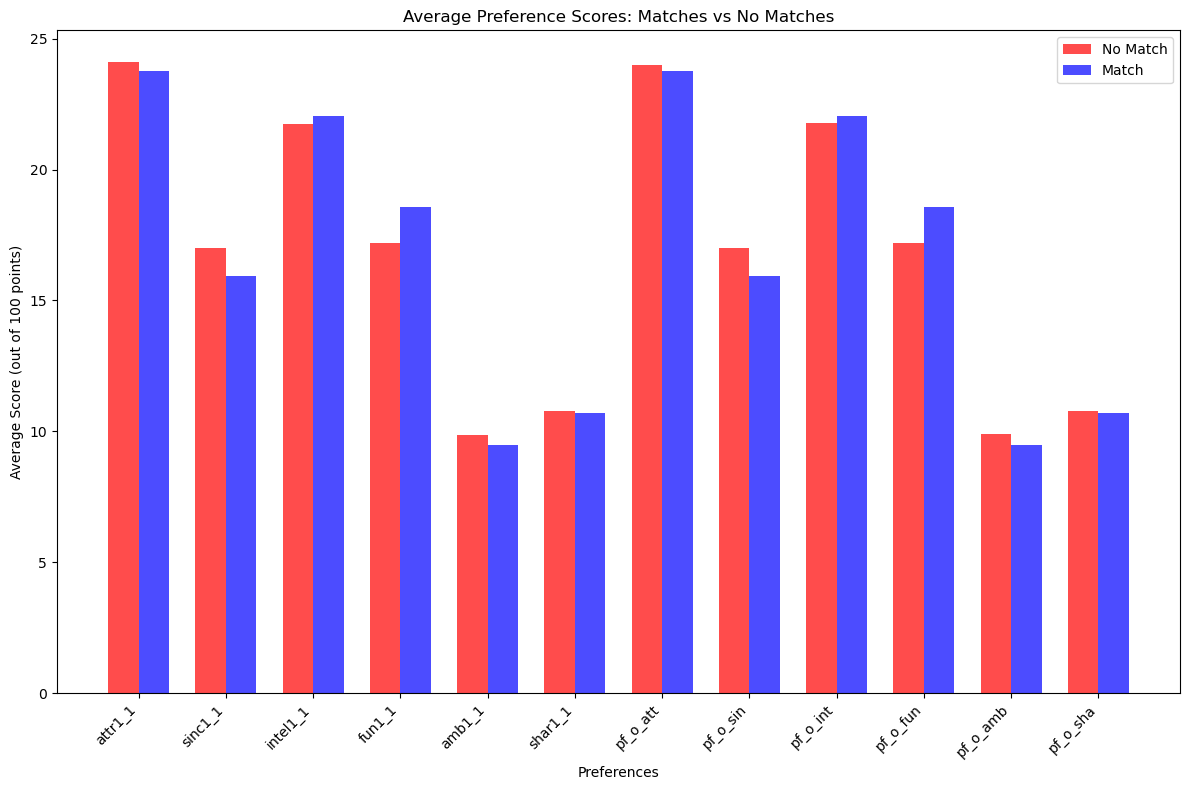


DETAILED LOOK AT KEY VARIABLES

fun1_1:
  Matches:    18.6 points
  No Matches: 17.2 points
  Difference: +1.4 points (+8.1%)
  → Matches value this MORE

pf_o_fun:
  Matches:    18.6 points
  No Matches: 17.2 points
  Difference: +1.4 points (+8.0%)
  → Matches value this MORE

sinc1_1:
  Matches:    15.9 points
  No Matches: 17.0 points
  Difference: -1.1 points (-6.3%)
  → Matches value this LESS

pf_o_att:
  Matches:    23.8 points
  No Matches: 24.0 points
  Difference: -0.2 points (-1.0%)
  → Matches value this LESS

amb1_1:
  Matches:    9.5 points
  No Matches: 9.9 points
  Difference: -0.4 points (-4.2%)
  → Matches value this LESS

QUICK SIGNIFICANCE CHECK

attr1_1:
  Matches: mean=23.8, std=13.7
  No Matches: mean=24.1, std=13.6
  → Small difference, likely noise

sinc1_1:
  Matches: mean=15.9, std=7.6
  No Matches: mean=17.0, std=7.2
  → Small difference, likely noise

intel1_1:
  Matches: mean=22.1, std=7.7
  No Matches: mean=21.7, std=7.7
  → Small difference, likely noi

In [67]:
#more EDA
print("AVERAGE PREFERENCE SCORES: MATCHES vs NO MATCHES")


# Group by match status and calculate means
match_analysis = dating_full.groupby('match')[model_b_cols].mean().T
match_analysis.columns = ['No Match (0)', 'Match (1)']
match_analysis['Difference'] = match_analysis['Match (1)'] - match_analysis['No Match (0)']

print("\nAverage Preference Scores:")
print(match_analysis.round(2))

# Sort by biggest differences
print("\nSorted by Biggest Difference (Match - No Match):")
print(match_analysis.sort_values('Difference', ascending=False).round(2))

# Bar chart comparing averages
plt.figure(figsize=(12, 8))
x = np.arange(len(model_b_cols))
width = 0.35

no_match_means = match_analysis['No Match (0)'].values
match_means = match_analysis['Match (1)'].values

plt.bar(x - width/2, no_match_means, width, label='No Match', alpha=0.7, color='red')
plt.bar(x + width/2, match_means, width, label='Match', alpha=0.7, color='blue')

plt.xlabel('Preferences')
plt.ylabel('Average Score (out of 100 points)')
plt.title('Average Preference Scores: Matches vs No Matches')
plt.xticks(x, model_b_cols, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Focus on the most interesting ones
interesting_vars = ['fun1_1', 'pf_o_fun', 'sinc1_1', 'pf_o_att', 'amb1_1']

print("\n" + "="*60)
print("DETAILED LOOK AT KEY VARIABLES")
print("="*60)

for var in interesting_vars:
    match_mean = dating_full[dating_full['match']==1][var].mean()
    no_match_mean = dating_full[dating_full['match']==0][var].mean()
    diff = match_mean - no_match_mean
    diff_pct = (diff / no_match_mean) * 100 if no_match_mean != 0 else 0
    
    print(f"\n{var}:")
    print(f"  Matches:    {match_mean:.1f} points")
    print(f"  No Matches: {no_match_mean:.1f} points")
    print(f"  Difference: {diff:+.1f} points ({diff_pct:+.1f}%)")
    
    if diff > 0:
        print(f"  → Matches value this MORE")
    else:
        print(f"  → Matches value this LESS")

print("\n" + "="*60)
print("QUICK SIGNIFICANCE CHECK")
print("="*60)

for var in model_b_cols[:6]:  # Just check first 6 for example
    match_data = dating_full[dating_full['match']==1][var]
    no_match_data = dating_full[dating_full['match']==0][var]
    
    match_std = match_data.std()
    no_match_std = no_match_data.std()
    
    print(f"\n{var}:")
    print(f"  Matches: mean={match_data.mean():.1f}, std={match_std:.1f}")
    print(f"  No Matches: mean={no_match_data.mean():.1f}, std={no_match_std:.1f}")
    
    # Simple rule of thumb: if means differ by more than 1 standard deviation
    if abs(match_data.mean() - no_match_data.mean()) > max(match_std, no_match_std):
        print(f"  → Potentially meaningful difference")
    else:
        print(f"  → Small difference, likely noise")

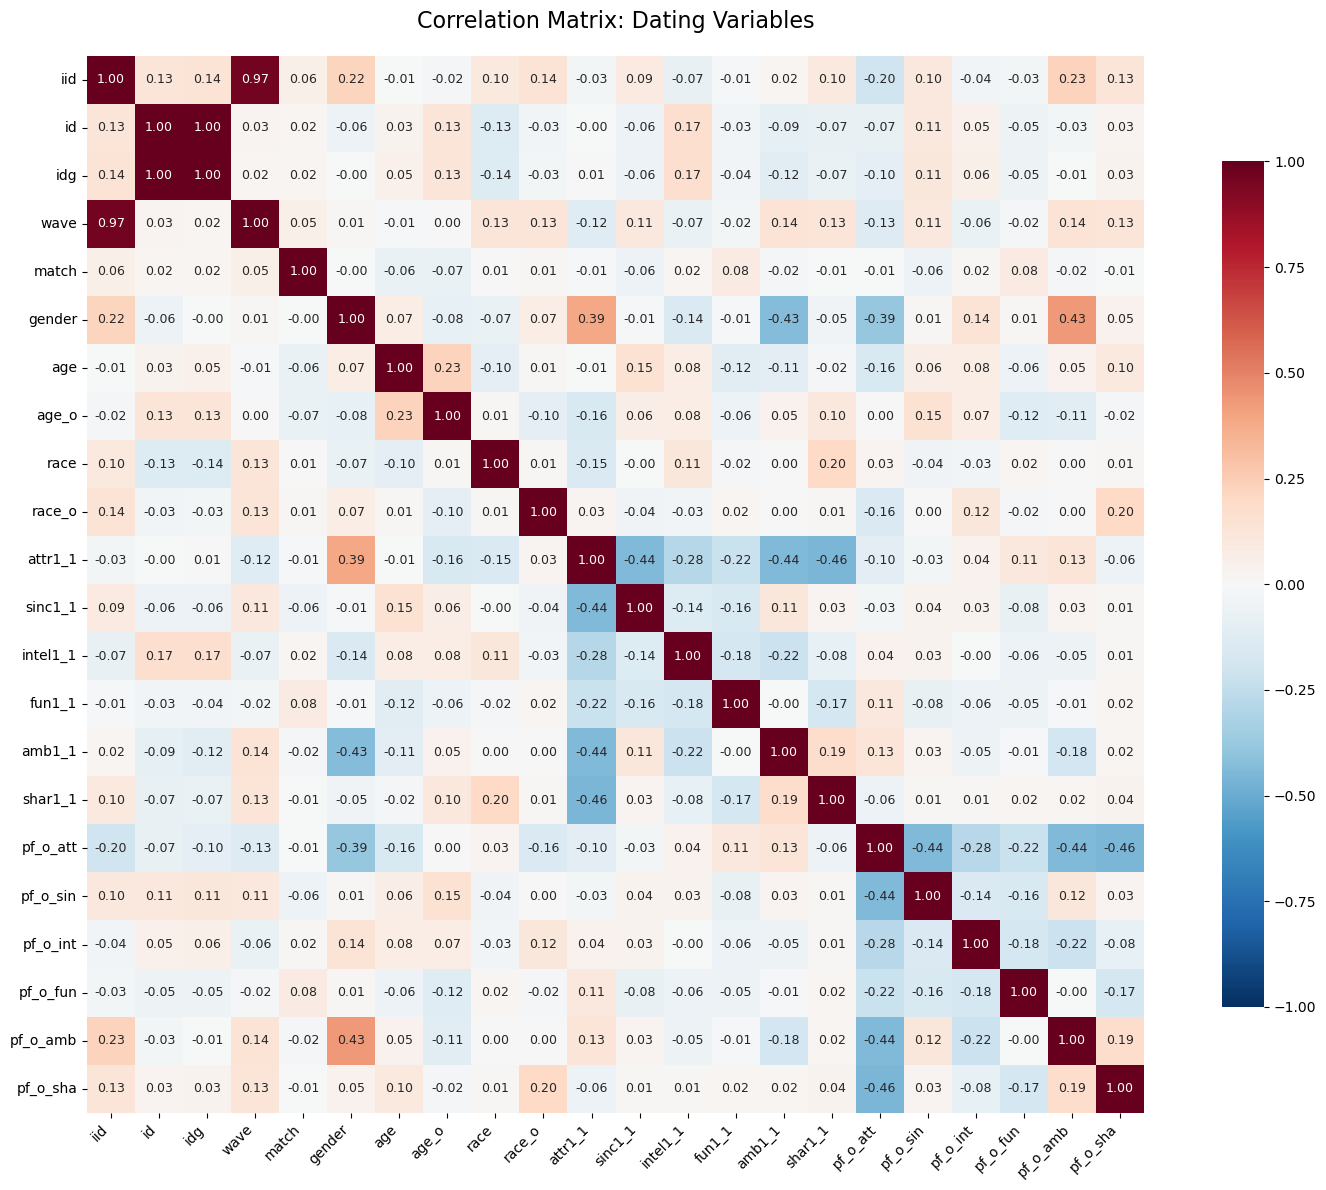

In [68]:
# correlation heatmap
plt.figure(figsize=(16, 12))

#correlation matrix
corr_matrix = dating_full.corr()

# Create the heatmap with better formatting
sns.heatmap(corr_matrix, 
            vmin=-1, 
            vmax=1, 
            annot=True,
            annot_kws={'size': 9},  # Smaller annotation font
            fmt='.2f',  # Show 2 decimal places
            cmap='RdBu_r',  # Better color scheme (red-blue)
            center=0,  # Center at 0
            square=True,  # Make cells square
            cbar_kws={'shrink': 0.8})  # Smaller color bar

plt.title('Correlation Matrix: Dating Variables', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

Data Preparation

In [43]:
dating = pd.read_csv(
    "Speed Dating Data.csv",
    encoding="latin1",
    skiprows=[1]
)

#renaming df to dating for cohesion with group partner's codes

In [44]:
dating.head()
dating.columns

Index(['iid', 'id', 'gender', 'idg', 'condtn', 'wave', 'round', 'position',
       'positin1', 'order',
       ...
       'attr3_3', 'sinc3_3', 'intel3_3', 'fun3_3', 'amb3_3', 'attr5_3',
       'sinc5_3', 'intel5_3', 'fun5_3', 'amb5_3'],
      dtype='object', length=195)

In [ ]:
# 1. SELECT COLUMNS
columns_to_keep = [
    'iid', 'id', 'idg', 'wave',
    'match',
    'gender',
    'age',
    'age_o',
    'race',
    'race_o',
    'attr1_1',
    'sinc1_1',
    'intel1_1',
    'fun1_1',
    'amb1_1',
    'shar1_1',
    'pf_o_att',
    'pf_o_sin',
    'pf_o_int',
    'pf_o_fun',
    'pf_o_amb',
    'pf_o_sha'
]

dating = dating[columns_to_keep].copy()



# 2. FILTER FOR WAVE 1–5
dating = dating[dating['wave'].between(1, 5)]
print(f"Shape after wave filtering (1-5): {dating.shape}")

 
# 3. EDA COPY (FULL sample: gender 0 + 1)
dating_full = dating.copy()  

# 4. MISSING VALUES REPORT (ONLY REPORT)
print("\nMissing values in each column (EDA view):")
print(dating_full.isna().sum())
 
# 5. MODELING DATASET
# Apply gender = 0 and drop missing vals
dating_model = dating_full[
    dating_full['gender'] == 0
].dropna().copy()

print(f"\nShape of modeling dataset (gender=0, dropna): {dating_model.shape}")

print("\nDataset info for modeling:")
dating_model.info()

Identifier Variables 
- iid: Unique subject identifier across the entire dataset
- id: Subject number within a given wave
- idg: Subject number within gender group within a wave
- wave: Speed-dating event (wave) number
These variables are used to track participants and are not treated as predictors

Binary categorical variables
- gender: participant gender (0 = female, 1 = male)
- match: mutual match outcome (1 = yes, 0 = no)
These variables represent categorical outcomes encoded numerically

All remaining variables are numeric 

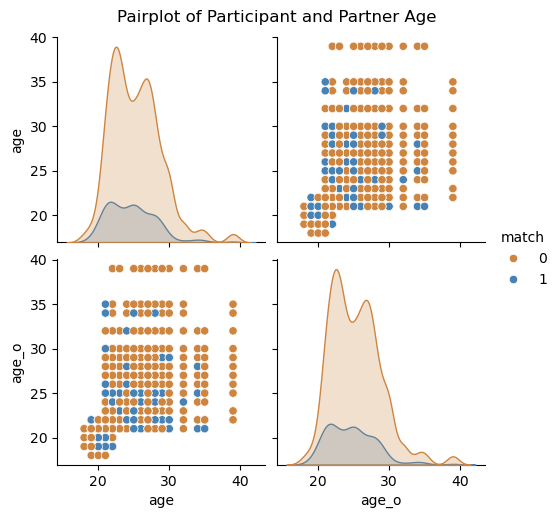

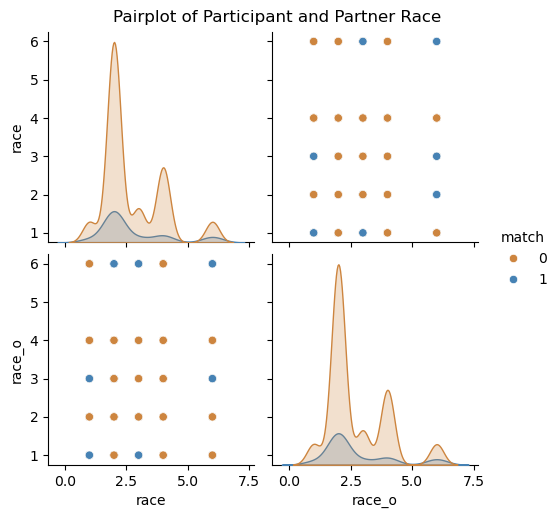

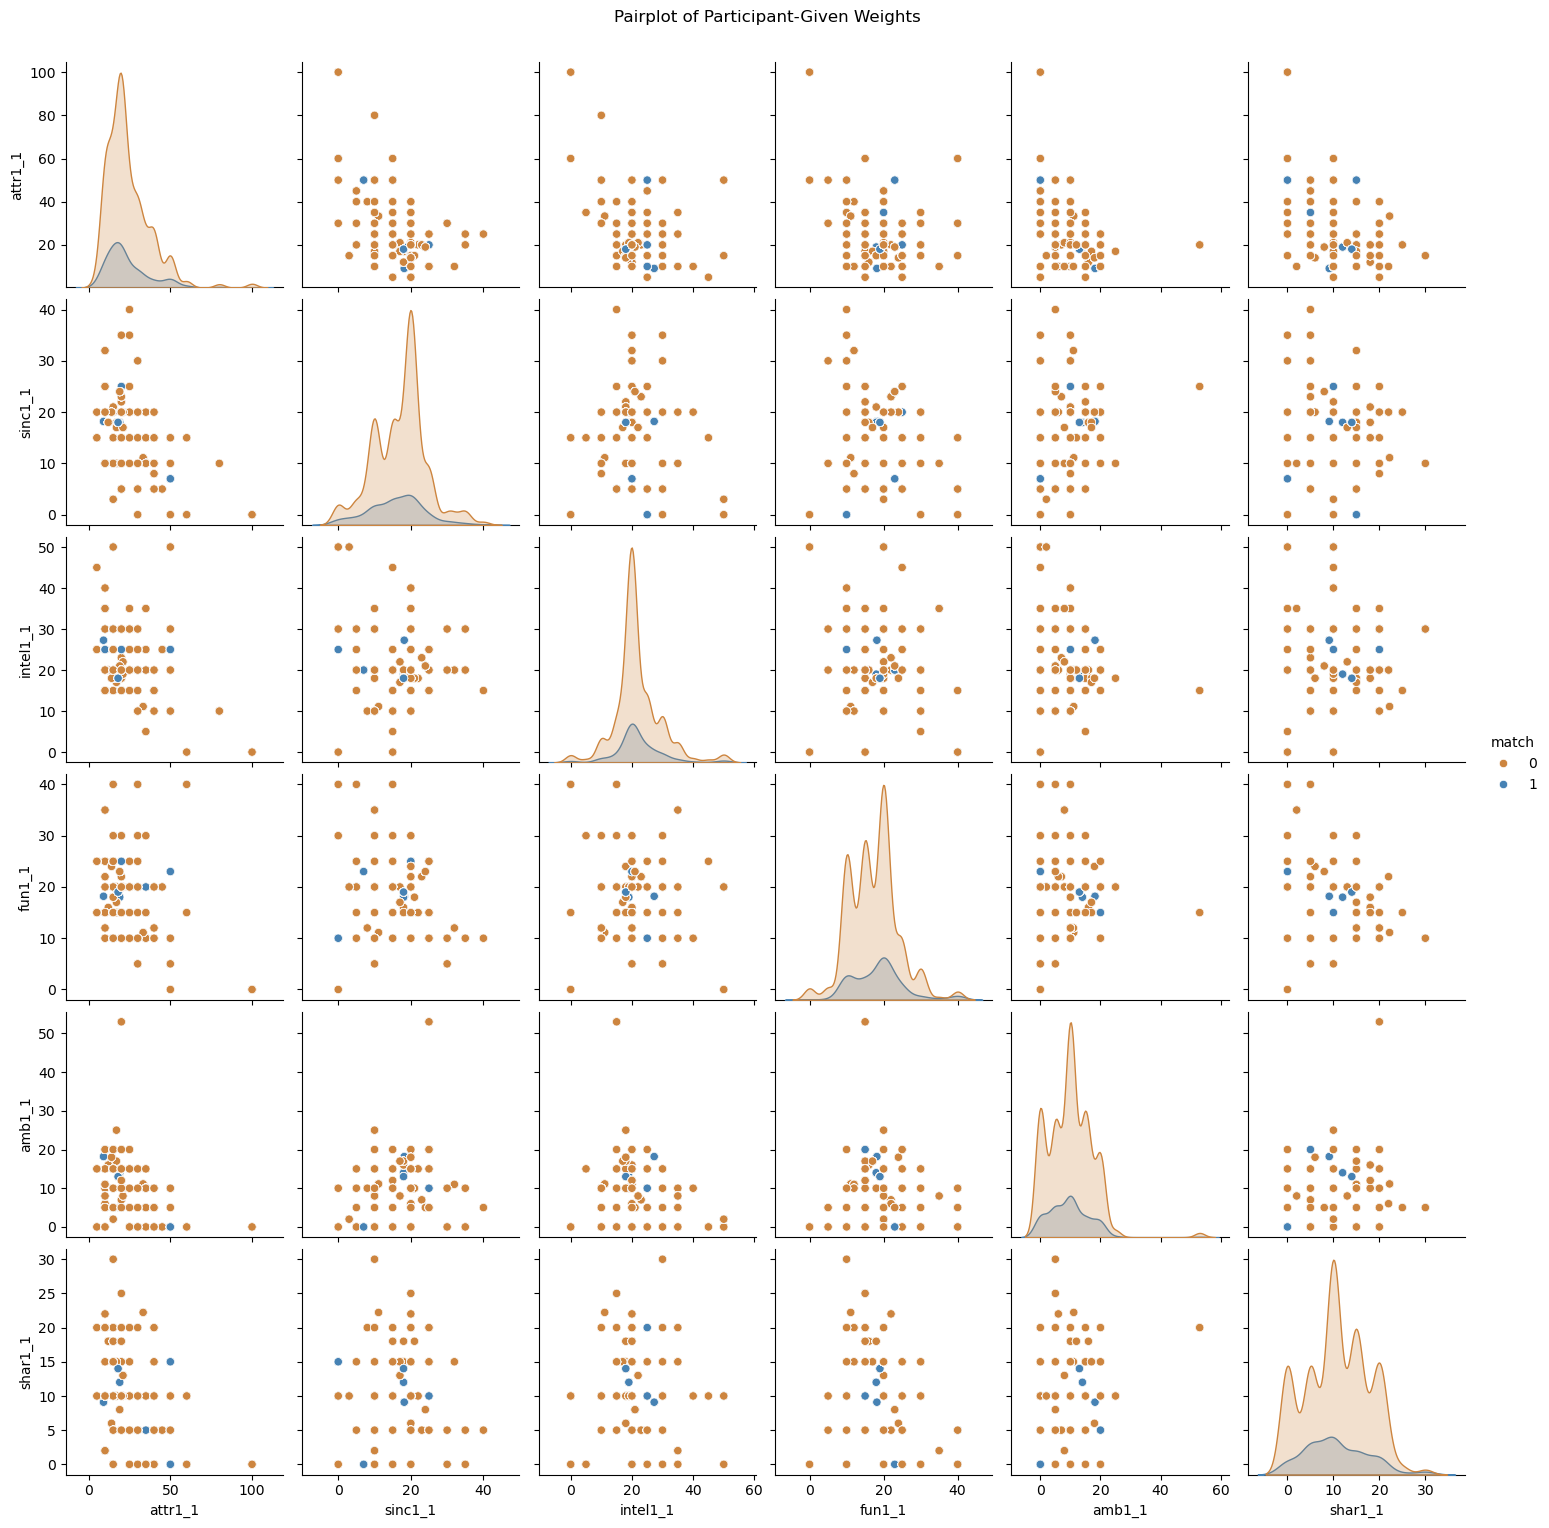

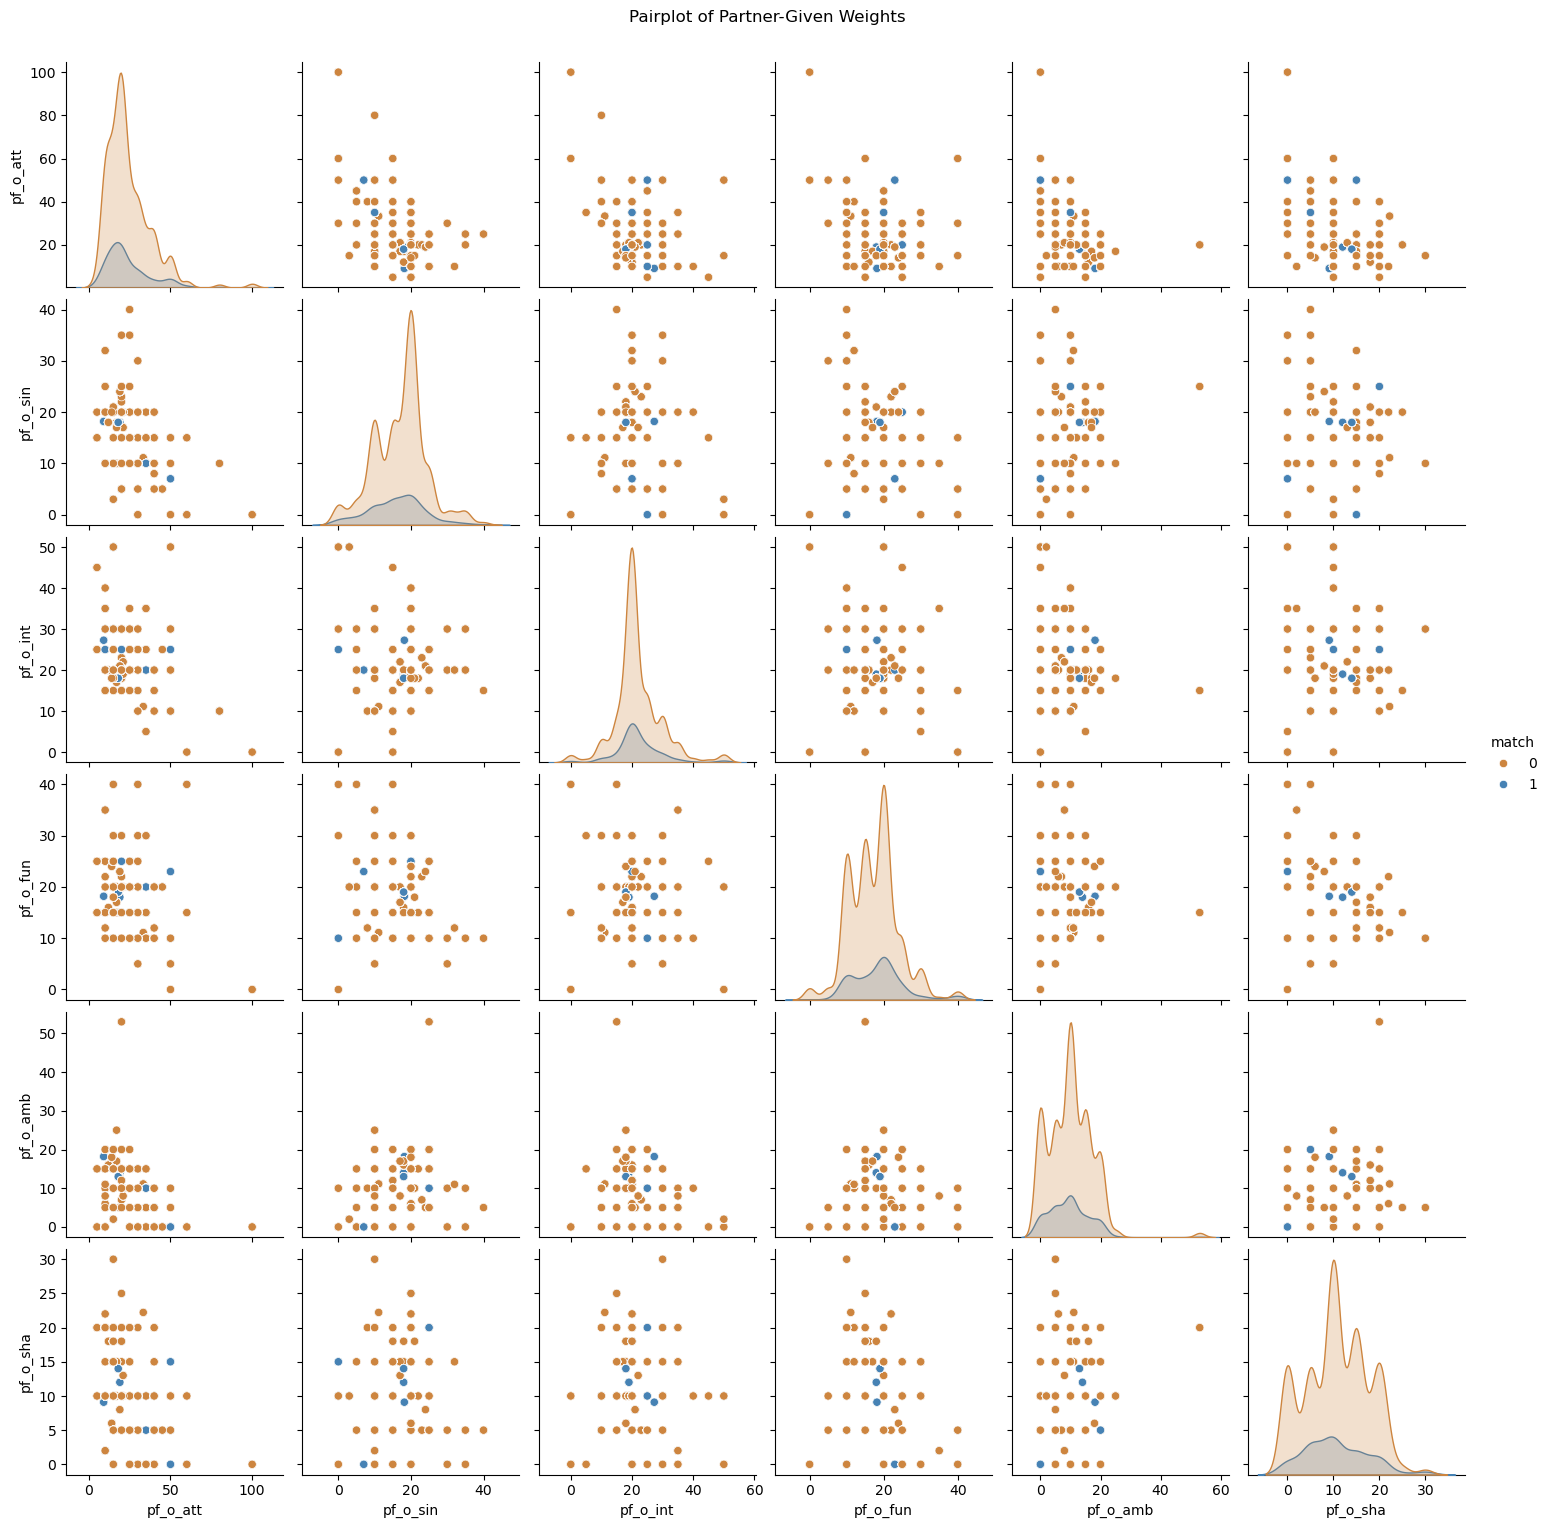

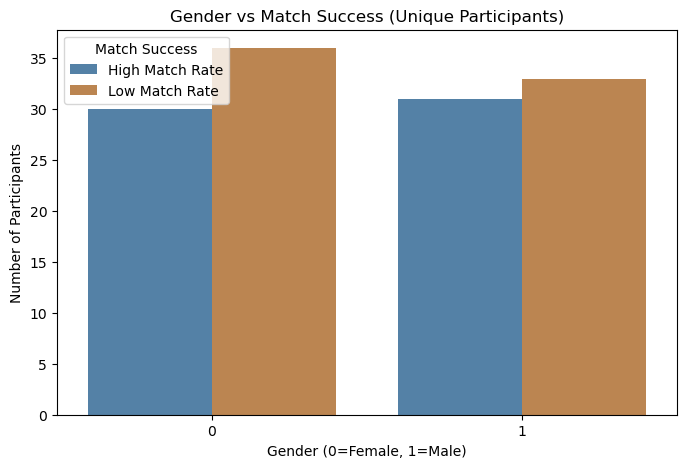

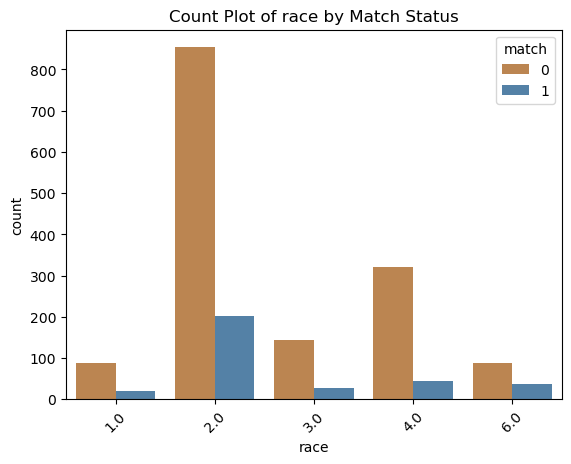

In [49]:
custom_palette = {'Low Match Rate': 'peru', 'High Match Rate': 'steelblue'}

pairplot_palette = {0: 'peru', 1: 'steelblue'}


pairplot_age = ['age', 'age_o']
if all(col in dating_full.columns for col in pairplot_age):
    sns.pairplot(dating_full, vars=pairplot_age, hue='match', palette=pairplot_palette)
    plt.suptitle('Pairplot of Participant and Partner Age', y=1.02)
    plt.show()

pairplot_race = ['race', 'race_o']
if all(col in dating_full.columns for col in pairplot_race):
    sns.pairplot(dating_full, vars=pairplot_race, hue='match', palette=pairplot_palette)
    plt.suptitle('Pairplot of Participant and Partner Race', y=1.02)
    plt.show()

pairplot1 = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1','amb1_1','shar1_1']
if all(col in dating_full.columns for col in pairplot1):
    sns.pairplot(dating_full, vars=pairplot1, hue='match', palette=pairplot_palette)
    plt.suptitle('Pairplot of Participant-Given Weights', y=1.02)
    plt.show()

pairplot2 = ['pf_o_att','pf_o_sin','pf_o_int','pf_o_fun','pf_o_amb','pf_o_sha']
if all(col in dating_full.columns for col in pairplot2):
    sns.pairplot(dating_full, vars=pairplot2, hue='match', palette=pairplot_palette)
    plt.suptitle('Pairplot of Partner-Given Weights', y=1.02)
    plt.show()

# Count plots for categorical variables
categorical_for_counts = ['gender', 'race']

for cat_var in categorical_for_counts:
    if cat_var in dating_full.columns:
        
        if cat_var == 'gender':
            # Create unique participant dataset
            dating_unique = dating_full.drop_duplicates(subset=['iid']).copy()
            
            # Calculate match success at participant level
            participant_match_stats = dating_full.groupby('iid').agg({
                'gender': 'first',
                'match': 'mean'  # Match rate for this participant
            }).reset_index()
            
            # Create binary: above/below median match rate
            median_rate = participant_match_stats['match'].median()
            participant_match_stats['match_category'] = participant_match_stats['match'].apply(
                lambda x: 'High Match Rate' if x > median_rate else 'Low Match Rate'
            )
            
            # Create corrected count plot
            plt.figure(figsize=(8, 5))
            sns.countplot(data=participant_match_stats, x='gender', hue='match_category', palette=custom_palette)
            plt.title('Gender vs Match Success (Unique Participants)')
            plt.xlabel('Gender (0=Female, 1=Male)')
            plt.ylabel('Number of Participants')
            plt.legend(title='Match Success')
            plt.show()
            
        else:
            # race plot uses numeric match values (0/1)
            plt.figure()
            sns.countplot(data=dating_full, x=cat_var, hue='match', palette=pairplot_palette)
            plt.title(f'Count Plot of {cat_var} by Match Status')
            plt.xticks(rotation=45)
            plt.show()

Preparing the data for modeling (Model A)

In [50]:
# Demographic predictors for Model A
demo_vars = ['age', 'age_o', 'race', 'race_o']

X = dating_model[demo_vars].copy()
y = dating_model['match']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nFeatures in X:")
for i, col in enumerate(X.columns):
    print(f"  {i+1:2d}. {col}")


X shape: (863, 4)
y shape: (863,)

Features in X:
   1. age
   2. age_o
   3. race
   4. race_o


Split data into training and test sets

In [51]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=11, stratify=y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=11, stratify=y
)

print(f"\nTraining set: X={X_train.shape}, match rate={y_train.mean():.3f}")
print(f"Test set: X={X_test.shape}, match rate={y_test.mean():.3f}")


Training set: X=(647, 4), match rate=0.184
Test set: X=(216, 4), match rate=0.185


Model type A: predict match w participants own weights a1: lasso a2: ridge

MODEL A: Participant Weights
MODEL A1: LASSO LOGISTIC REGRESSION CV
Model A1 Testing Accuracy: 0.5880
Predicted matches: 79 out of 216

Confusion Matrix:
True Negatives: 112 | False Positives: 64
False Negatives: 25 | True Positives: 15

Model A1 Classification Report:
              precision    recall  f1-score   support

    No Match       0.82      0.64      0.72       176
       Match       0.19      0.38      0.25        40

    accuracy                           0.59       216
   macro avg       0.50      0.51      0.48       216
weighted avg       0.70      0.59      0.63       216



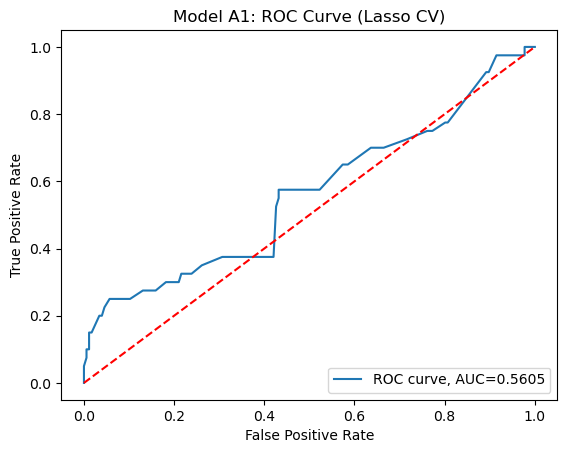

Model A1 AUC Score: 0.5605


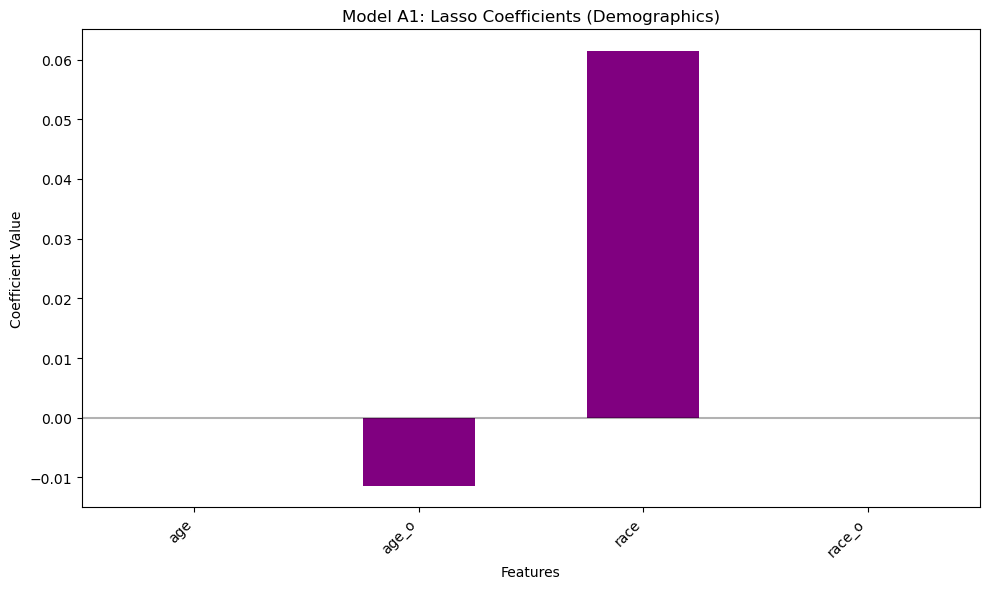


Model A1 Coefficients:
age: 0.0000
age_o: -0.0114
race: 0.0614
race_o: 0.0000
MODEL A2: RIDGE LOGISTIC REGRESSION CV
Model A2 Testing Accuracy: 0.8194
Predicted matches: 3 out of 216

Confusion Matrix:
True Negatives: 175 | False Positives: 1
False Negatives: 38 | True Positives: 2

Model A2 Classification Report:
              precision    recall  f1-score   support

    No Match       0.82      0.99      0.90       176
       Match       0.67      0.05      0.09        40

    accuracy                           0.82       216
   macro avg       0.74      0.52      0.50       216
weighted avg       0.79      0.82      0.75       216



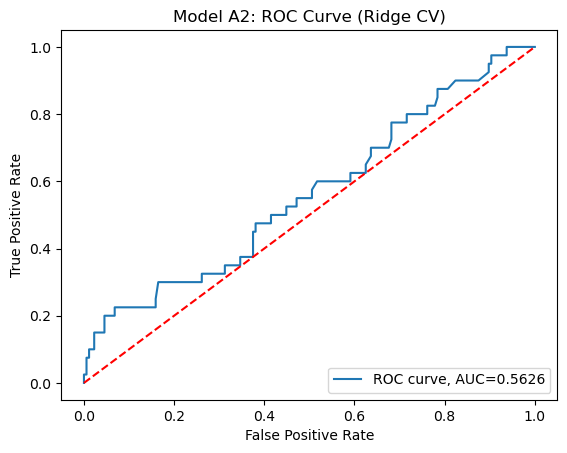

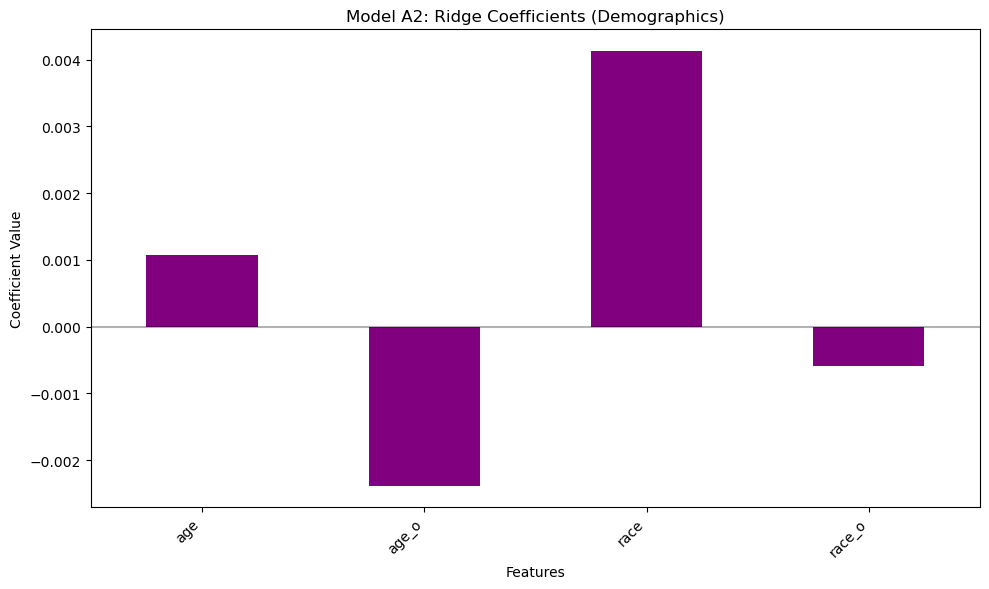


Model A2 Coefficients:
age: 0.0011
age_o: -0.0024
race: 0.0041
race_o: -0.0006


In [53]:
# =======================
# MODEL A
# =======================

print("MODEL A: Participant Weights")

class_names = ['No Match', 'Match']

# Model A uses ONLY demographic variables already in X_train and X_test
model_a_cols = demo_vars
X_train_a = X_train[model_a_cols]
X_test_a = X_test[model_a_cols]


# =======================
# MODEL A1: Lasso Logistic Regression CV
# =======================

print("MODEL A1: LASSO LOGISTIC REGRESSION CV")

logreg_a1 = LogisticRegressionCV(
    cv=5,
    penalty='l1',
    solver='saga',
    random_state=16,
    max_iter=5000,
    class_weight='balanced',
    tol=0.01
)
logreg_a1.fit(X_train_a, y_train)

test_accuracy_a1 = logreg_a1.score(X_test_a, y_test)
print(f"Model A1 Testing Accuracy: {test_accuracy_a1:.4f}")

test_pred_a1 = logreg_a1.predict(X_test_a)
print(f"Predicted matches: {test_pred_a1.sum()} out of {len(test_pred_a1)}")

test_cm_a1 = confusion_matrix(y_test, test_pred_a1)
print(f"\nConfusion Matrix:")
print(f"True Negatives: {test_cm_a1[0,0]} | False Positives: {test_cm_a1[0,1]}")
print(f"False Negatives: {test_cm_a1[1,0]} | True Positives: {test_cm_a1[1,1]}")

print("\nModel A1 Classification Report:")
print(classification_report(y_test, test_pred_a1, target_names=class_names, zero_division=0))

test_pprob_a1 = logreg_a1.predict_proba(X_test_a)
fpr_a1, tpr_a1, _ = roc_curve(y_test, test_pprob_a1[:, 1])
auc_a1 = roc_auc_score(y_test, test_pprob_a1[:, 1])

plt.plot(fpr_a1, tpr_a1, label=f"ROC curve, AUC={auc_a1:.4f}")
plt.plot([0, 1], [0, 1], 'r--')
plt.legend(loc=4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model A1: ROC Curve (Lasso CV)')
plt.show()

print(f"Model A1 AUC Score: {auc_a1:.4f}")

coefficients_a1 = pd.Series(logreg_a1.coef_[0], index=model_a_cols)
plt.figure(figsize=(10, 6))
coefficients_a1.plot(
    kind='bar',
    color='purple'   
)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Model A1: Lasso Coefficients (Demographics)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nModel A1 Coefficients:")
for name, coef in coefficients_a1.items():
    print(f"{name}: {coef:.4f}")


# =======================
# MODEL A2: RIDGE
# =======================

print("MODEL A2: RIDGE LOGISTIC REGRESSION CV")

logreg_a2 = LogisticRegressionCV(
    cv=5,
    penalty='l2',
    random_state=16,
    max_iter=5000,
    class_weight='balanced',
    tol=0.01
)
logreg_a2.fit(X_train_a, y_train)

test_accuracy_a2 = logreg_a2.score(X_test_a, y_test)
print(f"Model A2 Testing Accuracy: {test_accuracy_a2:.4f}")

test_pred_a2 = logreg_a2.predict(X_test_a)
print(f"Predicted matches: {test_pred_a2.sum()} out of {len(test_pred_a2)}")

test_cm_a2 = confusion_matrix(y_test, test_pred_a2)
print(f"\nConfusion Matrix:")
print(f"True Negatives: {test_cm_a2[0,0]} | False Positives: {test_cm_a2[0,1]}")
print(f"False Negatives: {test_cm_a2[1,0]} | True Positives: {test_cm_a2[1,1]}")

print("\nModel A2 Classification Report:")
print(classification_report(y_test, test_pred_a2, target_names=class_names, zero_division=0))

test_pprob_a2 = logreg_a2.predict_proba(X_test_a)
fpr_a2, tpr_a2, _ = roc_curve(y_test, test_pprob_a2[:, 1])
auc_a2 = roc_auc_score(y_test, test_pprob_a2[:, 1])

plt.plot(fpr_a2, tpr_a2, label=f"ROC curve, AUC={auc_a2:.4f}")
plt.plot([0, 1], [0, 1], 'r--')
plt.legend(loc=4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model A2: ROC Curve (Ridge CV)')
plt.show()

coefficients_a2 = pd.Series(logreg_a2.coef_[0], index=model_a_cols)

plt.figure(figsize=(10, 6))
coefficients_a2.plot(
    kind='bar',
    color='purple'
)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Model A2: Ridge Coefficients (Demographics)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


print(f"\nModel A2 Coefficients:")
for name, coef in coefficients_a2.items():
    print(f"{name}: {coef:.4f}")

Model B Data Prep

In [61]:
# Model B predictors
model_b_cols = [
    'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1',
    'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha'
]

X_full_B = dating_model[model_b_cols]

# Use SAME train/test split indices
X_train_b = X_full_B.loc[X_train.index]
X_test_b  = X_full_B.loc[X_test.index]

print(f"Model B uses {len(model_b_cols)} rating variables:")
print(model_b_cols)

Model B uses 12 rating variables:
['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', 'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha']


MODEL B1: LASSO LOGISTIC REGRESSION (CV)
Testing Accuracy: 0.6481
Predicted matches: 90 out of 216

Confusion Matrix:
True Negatives: 113 | False Positives: 63
False Negatives: 13 | True Positives: 27

Classification Report:
              precision    recall  f1-score   support

    No Match       0.90      0.64      0.75       176
       Match       0.30      0.68      0.42        40

    accuracy                           0.65       216
   macro avg       0.60      0.66      0.58       216
weighted avg       0.79      0.65      0.69       216



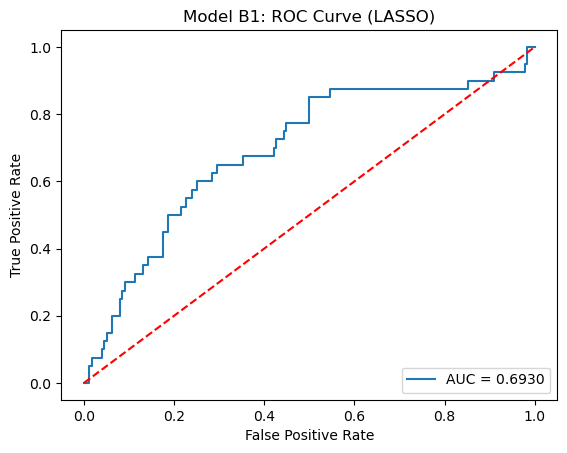

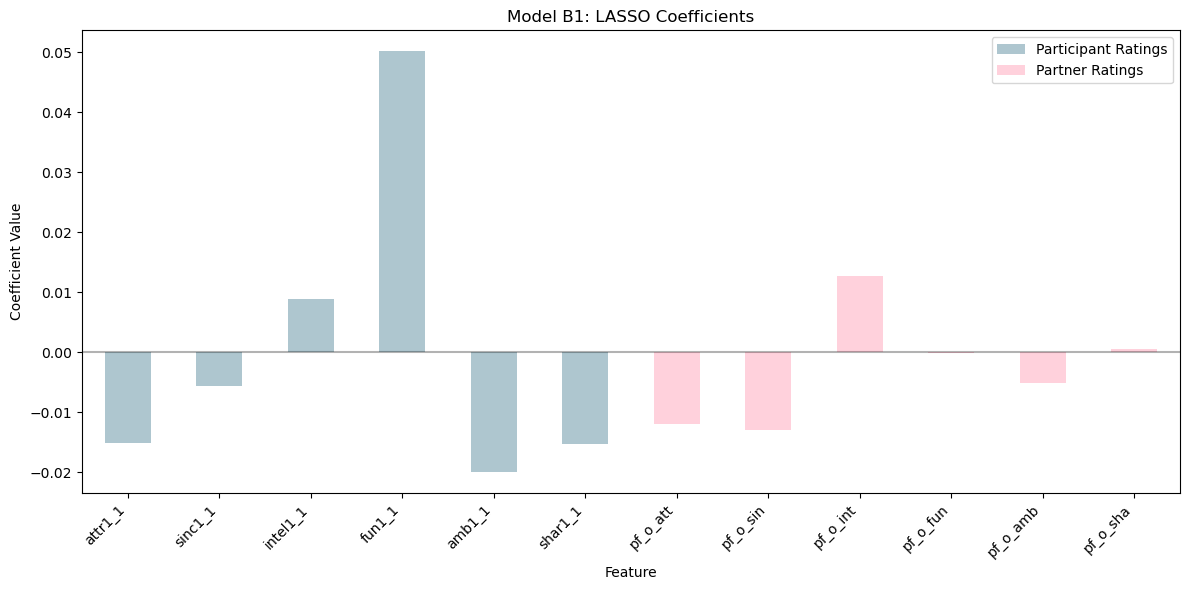


Model B1 Coefficients:
attr1_1: -0.0152 
sinc1_1: -0.0056 
intel1_1: 0.0089 
fun1_1: 0.0501 
amb1_1: -0.0200 
shar1_1: -0.0152 
pf_o_att: -0.0119 
pf_o_sin: -0.0130 
pf_o_int: 0.0127 
pf_o_fun: -0.0001 
pf_o_amb: -0.0051 
pf_o_sha: 0.0005 

Non-zero coefficients: 12 / 12

MODEL B2: RIDGE LOGISTIC REGRESSION (CV)
Testing Accuracy: 0.6389
Predicted matches: 90 out of 216

Confusion Matrix:
True Negatives: 112 | False Positives: 64
False Negatives: 14 | True Positives: 26

Classification Report:
              precision    recall  f1-score   support

    No Match       0.89      0.64      0.74       176
       Match       0.29      0.65      0.40        40

    accuracy                           0.64       216
   macro avg       0.59      0.64      0.57       216
weighted avg       0.78      0.64      0.68       216



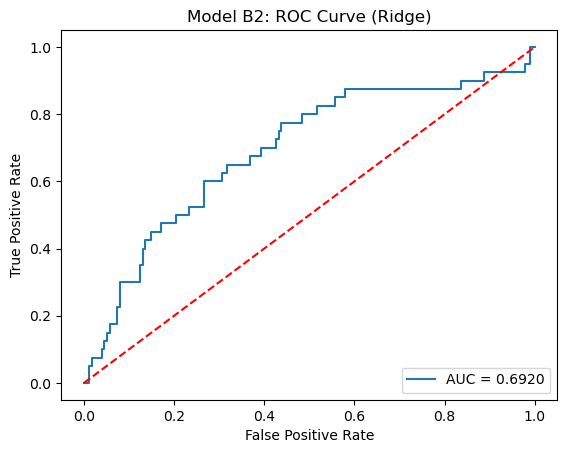

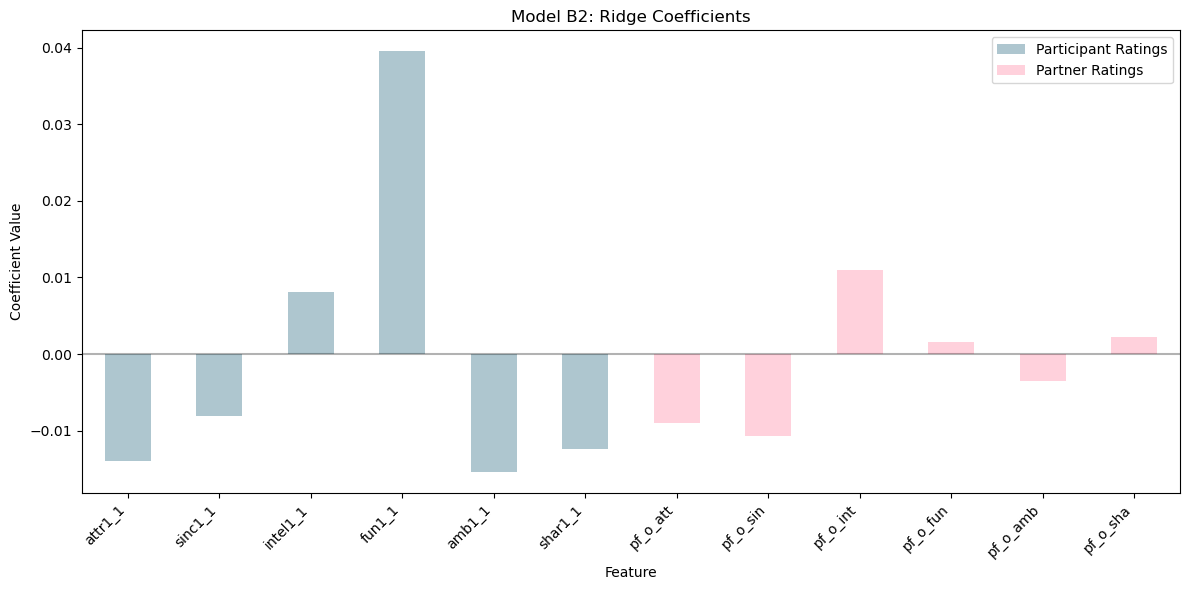


Model B2 Coefficients:
attr1_1: -0.0140
sinc1_1: -0.0081
intel1_1: 0.0081
fun1_1: 0.0395
amb1_1: -0.0154
shar1_1: -0.0124
pf_o_att: -0.0090
pf_o_sin: -0.0107
pf_o_int: 0.0110
pf_o_fun: 0.0016
pf_o_amb: -0.0035
pf_o_sha: 0.0023


In [66]:
# =======================
# COLOR SETUP
# =======================

pastel_blue = "#AEC6CF"
pastel_pink = "#FFD1DC"

participant_cols = [
    'attr1_1', 'sinc1_1', 'intel1_1',
    'fun1_1', 'amb1_1', 'shar1_1'
]

partner_cols = [
    'pf_o_att', 'pf_o_sin', 'pf_o_int',
    'pf_o_fun', 'pf_o_amb', 'pf_o_sha'
]

color_map = [
    pastel_blue if col in participant_cols else pastel_pink
    for col in model_b_cols
]

# =======================
# MODEL B1: LASSO
# =======================

print("MODEL B1: LASSO LOGISTIC REGRESSION (CV)")

logreg_b1 = LogisticRegressionCV(
    cv=5,
    penalty="l1",
    solver="saga",
    random_state=16,
    max_iter=5000,
    class_weight="balanced",
    tol=0.01
)

logreg_b1.fit(X_train_b, y_train)

coefficients_b1 = pd.Series(
    logreg_b1.coef_[0],
    index=model_b_cols
)

# Accuracy & predictions
test_accuracy_b1 = logreg_b1.score(X_test_b, y_test)
test_pred_b1 = logreg_b1.predict(X_test_b)

print(f"Testing Accuracy: {test_accuracy_b1:.4f}")
print(f"Predicted matches: {test_pred_b1.sum()} out of {len(test_pred_b1)}")

# Confusion matrix
cm_b1 = confusion_matrix(y_test, test_pred_b1)
print("\nConfusion Matrix:")
print(f"True Negatives: {cm_b1[0,0]} | False Positives: {cm_b1[0,1]}")
print(f"False Negatives: {cm_b1[1,0]} | True Positives: {cm_b1[1,1]}")

print("\nClassification Report:")
print(classification_report(y_test, test_pred_b1, target_names=class_names, zero_division=0))

# ROC Curve
test_pprob_b1 = logreg_b1.predict_proba(X_test_b)[:, 1]
fpr_b1, tpr_b1, _ = roc_curve(y_test, test_pprob_b1)
auc_b1 = roc_auc_score(y_test, test_pprob_b1)

plt.figure()
plt.plot(fpr_b1, tpr_b1, label=f"AUC = {auc_b1:.4f}")
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model B1: ROC Curve (LASSO)")
plt.legend(loc="lower right")
plt.show()

# Coefficient plot
plt.figure(figsize=(12, 6))
coefficients_b1.plot(kind="bar", color=color_map)
plt.axhline(0, color="black", alpha=0.3)
plt.title("Model B1: LASSO Coefficients")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")

legend_handles = [
    Patch(facecolor=pastel_blue, label="Participant Ratings"),
    Patch(facecolor=pastel_pink, label="Partner Ratings")
]
plt.legend(handles=legend_handles)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nModel B1 Coefficients:")
for name, coef in coefficients_b1.items():
    label = "(zeroed by LASSO)" if coef == 0 else ""
    print(f"{name}: {coef:.4f} {label}")

print(f"\nNon-zero coefficients: {(coefficients_b1 != 0).sum()} / {len(coefficients_b1)}")

# =======================
# MODEL B2: RIDGE
# =======================

print("\nMODEL B2: RIDGE LOGISTIC REGRESSION (CV)")

logreg_b2 = LogisticRegressionCV(
    cv=5,
    penalty="l2",
    random_state=16,
    max_iter=5000,
    class_weight="balanced",
    tol=0.01
)

logreg_b2.fit(X_train_b, y_train)

coefficients_b2 = pd.Series(
    logreg_b2.coef_[0],
    index=model_b_cols
)

# Accuracy & predictions
test_accuracy_b2 = logreg_b2.score(X_test_b, y_test)
test_pred_b2 = logreg_b2.predict(X_test_b)

print(f"Testing Accuracy: {test_accuracy_b2:.4f}")
print(f"Predicted matches: {test_pred_b2.sum()} out of {len(test_pred_b2)}")

# Confusion matrix
cm_b2 = confusion_matrix(y_test, test_pred_b2)
print("\nConfusion Matrix:")
print(f"True Negatives: {cm_b2[0,0]} | False Positives: {cm_b2[0,1]}")
print(f"False Negatives: {cm_b2[1,0]} | True Positives: {cm_b2[1,1]}")

print("\nClassification Report:")
print(classification_report(y_test, test_pred_b2, target_names=class_names, zero_division=0))

# ROC Curve
test_pprob_b2 = logreg_b2.predict_proba(X_test_b)[:, 1]
fpr_b2, tpr_b2, _ = roc_curve(y_test, test_pprob_b2)
auc_b2 = roc_auc_score(y_test, test_pprob_b2)

plt.figure()
plt.plot(fpr_b2, tpr_b2, label=f"AUC = {auc_b2:.4f}")
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model B2: ROC Curve (Ridge)")
plt.legend(loc="lower right")
plt.show()

# Coefficient plot
plt.figure(figsize=(12, 6))
coefficients_b2.plot(kind="bar", color=color_map)
plt.axhline(0, color="black", alpha=0.3)
plt.title("Model B2: Ridge Coefficients")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.legend(handles=legend_handles)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nModel B2 Coefficients:")
for name, coef in coefficients_b2.items():
    print(f"{name}: {coef:.4f}")
